# Loading package

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import h5py # Read the H5 file
import napari
import xarray as xr

# Import the mouvement package and functions
import movement 
from movement.io import load_dataset
from movement.filtering import filter_by_confidence, rolling_filter, interpolate_over_time
from movement.kinematics import compute_velocity
from movement.plots import plot_centroid_trajectory
from movement.roi import PolygonOfInterest, load_rois

# Loading Data
Loading the H5 file exported from SLEAP, the aim is to track the fly's steps in a top-view. Training for the tracking is already done. 

In [13]:
filename = "/Users/margotrefuge/osss/data/fly_top_view/labels.v001-cs-01.000_cs-1-trial 0.analysis.h5"

# Inspect H5 file

Overview of the metadata's file : 
- File name,
- Location data shape 
- Skeleton (keypoints)
- Number of frame 

In [14]:
with h5py.File(filename, "r") as f:
    dset_names = list(f.keys())
    locations = f["tracks"][:].T
    node_names = [n.decode() for n in f["node_names"][:]]

print("filename :", filename)

print("HDF5 datasets :", dset_names) 

print("locations data shape :", locations.shape)

print("skeleton :")
for i, name in enumerate(node_names):
    print(f"{i}: {name}")

frame_count, node_count, _, instance_count = locations.shape
print("frame count:", frame_count)

filename : /Users/margotrefuge/osss/data/fly_top_view/labels.v001-cs-01.000_cs-1-trial 0.analysis.h5
HDF5 datasets : ['edge_inds', 'edge_names', 'instance_scores', 'labels_path', 'node_names', 'point_scores', 'provenance', 'track_names', 'track_occupancy', 'tracking_scores', 'tracks', 'video_ind', 'video_path']
locations data shape : (196, 9, 2, 1)
skeleton :
0: head
1: thorax
2: belly
3: LF
4: RF
5: LM
6: RM
7: LR
8: RR
frame count: 196


# Inspect Data 

In [15]:
ds = load_dataset(filename)

In [16]:
ds

<xarray.Dataset> Size: 23kB
Dimensions:     (time: 196, space: 2, keypoint: 9, individual: 1)
Coordinates:
  * time        (time) int64 2kB 0 1 2 3 4 5 6 7 ... 189 190 191 192 193 194 195
  * space       (space) <U1 8B 'x' 'y'
  * keypoint    (keypoint) <U6 216B 'head' 'thorax' 'belly' ... 'RM' 'LR' 'RR'
  * individual  (individual) <U4 16B 'id_0'
Data variables:
    position    (time, space, keypoint, individual) float32 14kB 2.082e+03 .....
    confidence  (time, keypoint, individual) float32 7kB 0.8824 ... 0.7143
Attributes:
    source_software:  SLEAP
    ds_type:          poses
    time_unit:        frames
    source_file:      /Users/margotrefuge/osss/data/fly_top_view/labels.v001-...

## Inspect Confidence 
### Distribution of all dataset 

(array([ 80.,  21.,  56.,  83., 118., 214., 381., 330.,  33.,   7.]),
 array([0.        , 0.13068797, 0.26137593, 0.39206392, 0.52275187,
        0.65343982, 0.78412783, 0.91481578, 1.04550374, 1.17619169,
        1.30687964]),
 <BarContainer object of 10 artists>)

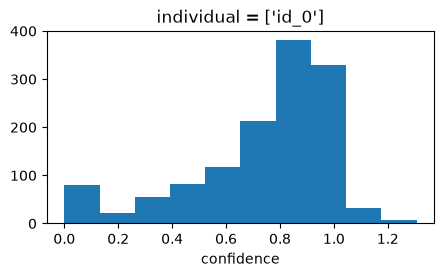

In [17]:
# Select the confidence of all the dataset 
conf = ds.confidence
conf.plot.hist(aspect=2, size=2.5)

### Per keypoints 
We are looking at the fly's paws only. 

In [18]:
# Select only the keypoints of interest + select the confidence variables
key_conf = ds.sel(keypoint=["LF","RF","RM","LM","LR","RR"]).confidence
key_conf

<xarray.DataArray 'confidence' (time: 196, keypoint: 6, individual: 1)> Size: 5kB
0.5992 0.7091 0.5271 0.0 0.6772 0.3813 ... 0.5416 0.6836 0.8863 0.8253 0.7143
Coordinates:
  * time        (time) int64 2kB 0 1 2 3 4 5 6 7 ... 189 190 191 192 193 194 195
  * keypoint    (keypoint) <U6 144B 'LF' 'RF' 'RM' 'LM' 'LR' 'RR'
  * individual  (individual) <U4 16B 'id_0'

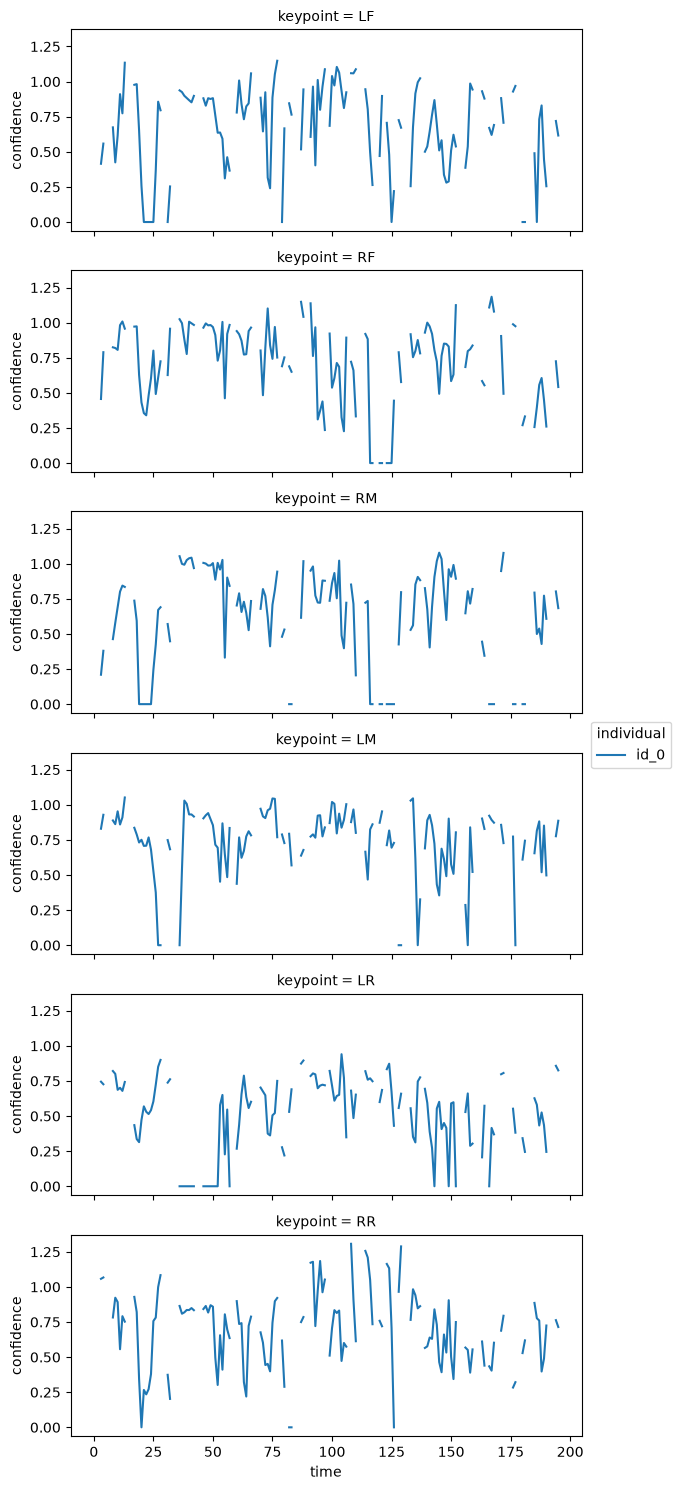

In [19]:
# Plot it 
key_conf.plot.line(x="time", row="keypoint", aspect=2, size=2.5)

## Cleaning data 

In [20]:
# Filter function by confidence
position_filtered = filter_by_confidence(
    ds.position, ds.confidence, threshold=0.7, print_report=True
)

Missing points (marked as NaN) in input:

keypoint                LF              RF              LM               RM               LR             RR
individual                                                                                                 
id_0        19/196 (9.69%)  11/196 (5.61%)  14/196 (7.14%)  33/196 (16.84%)  22/196 (11.22%)  7/196 (3.57%)
Missing points (marked as NaN) in output:

keypoint               head           thorax            belly                LF                RF               LM                RM                LR                RR
individual                                                                                                                                                              
id_0        50/196 (25.51%)  55/196 (28.06%)  56/196 (28.57%)  116/196 (59.18%)  103/196 (52.55%)  97/196 (49.49%)  119/196 (60.71%)  156/196 (79.59%)  111/196 (56.63%)


### Missing values

We can observed that : 
- LF : Front leg left : 9.69% of values are missing
- RF : Front leg right : 5.61% of values are missing
- LM : Middle leg left : 7.14% of values are missing
- RM : Middle leg right : 16.84% of values are missing
- RL : Hind (R) leg left : 11.22% of values are missing
- RR : Hind (R) leg right : 3.57% of values are missing

In [21]:
# Only extracted keypoints of interest 
pos_filtered_int = position_filtered.sel(keypoint=["LF","RF","LM", "RM", "RR", "LR"])

# Extract only keypoints of interest and their position : x
pos_filtered_int_x = position_filtered.sel(keypoint=["LF","RF","LM", "RM", "RR", "LR"], space="x")

# Extract only keypoints of interest and their position : y
pos_filtered_int_y = position_filtered.sel(keypoint=["LF","RF","LM", "RM", "RR", "LR"], space="y")


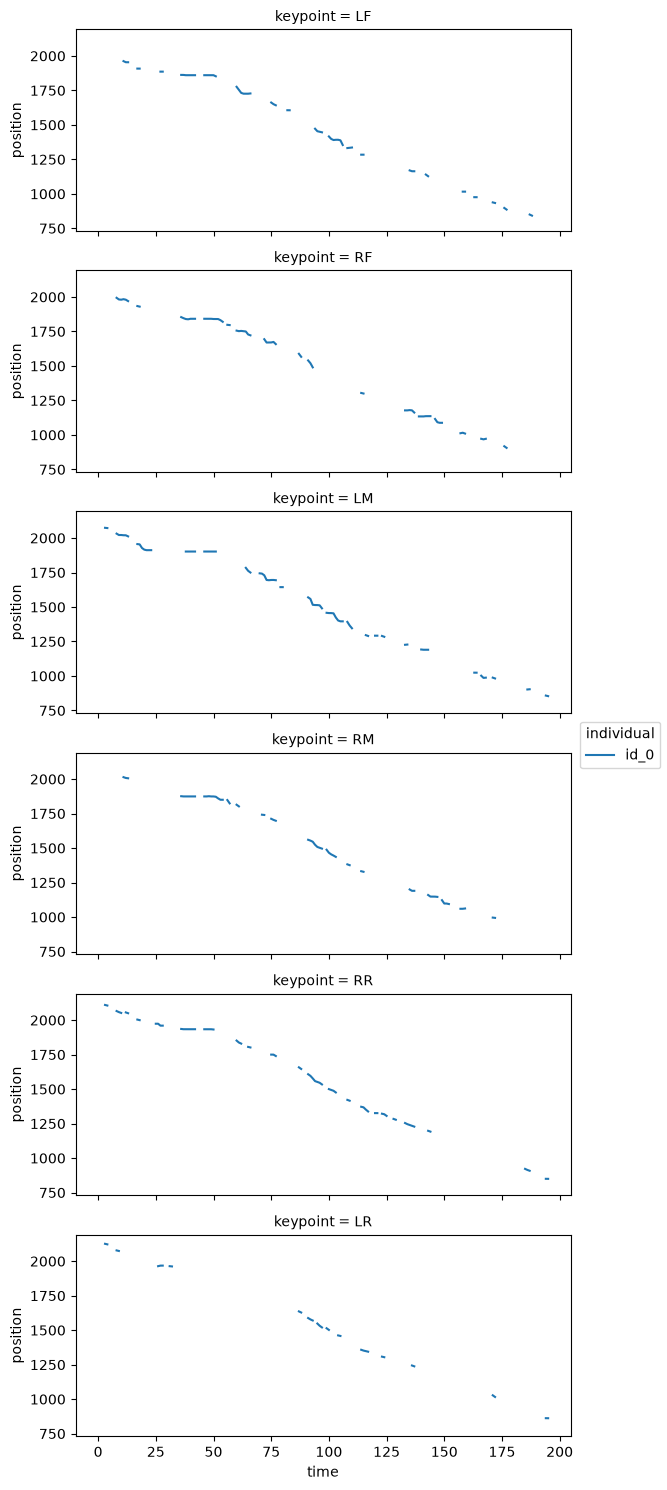

In [22]:
# Plot each keypoint position (x) in the y axis over time

pos_filtered_int_x.plot.line(x = "time",row = "keypoint", aspect = 2, size = 2.5)

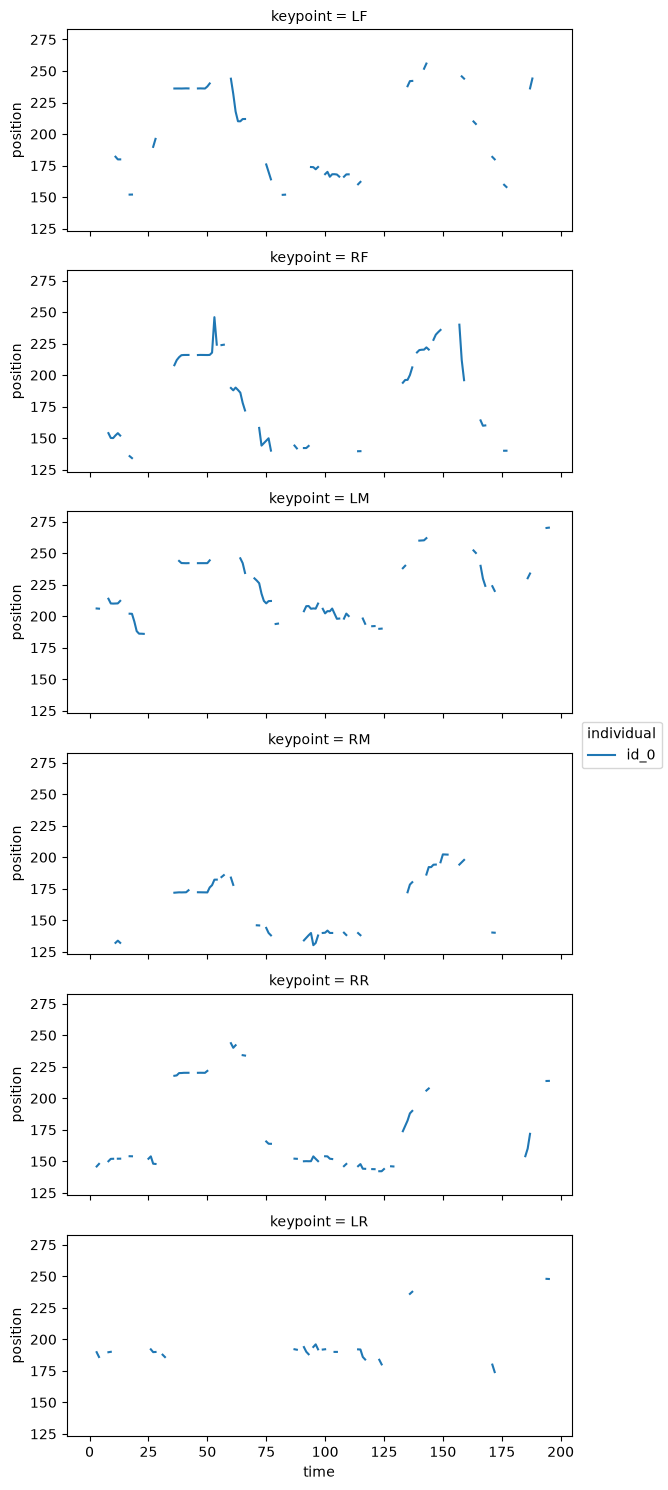

In [23]:
# Plot each keypoint position (y) in the y axis over time

pos_filtered_int_y.plot.line(x = "time",row = "keypoint", aspect = 2, size = 2.5)

### Rolling median filter
Can suppress noise by replacing each value with the median of the surrounding frames within a sliding window.

In [24]:
# We have to choose a window, a statistic, min_periods
position_smooth = rolling_filter(
    position_filtered, window=5, statistic="median",min_periods=2
)

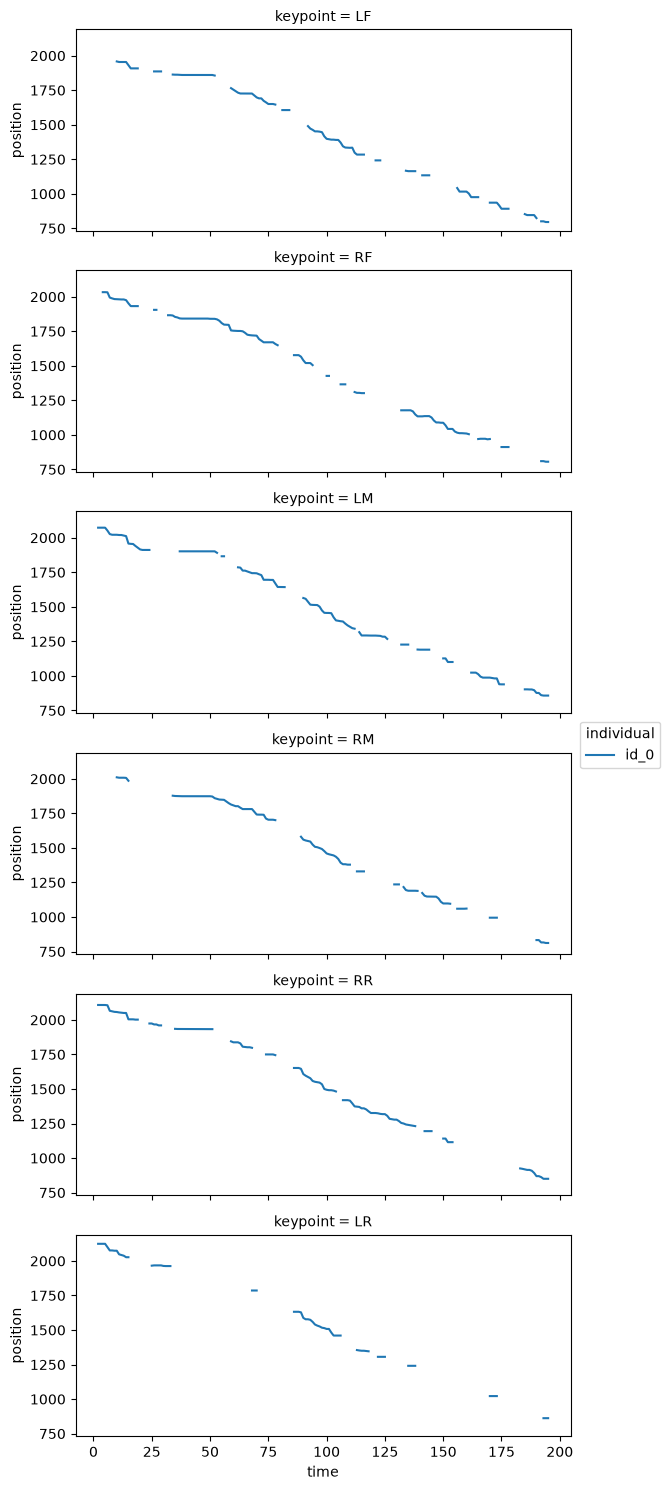

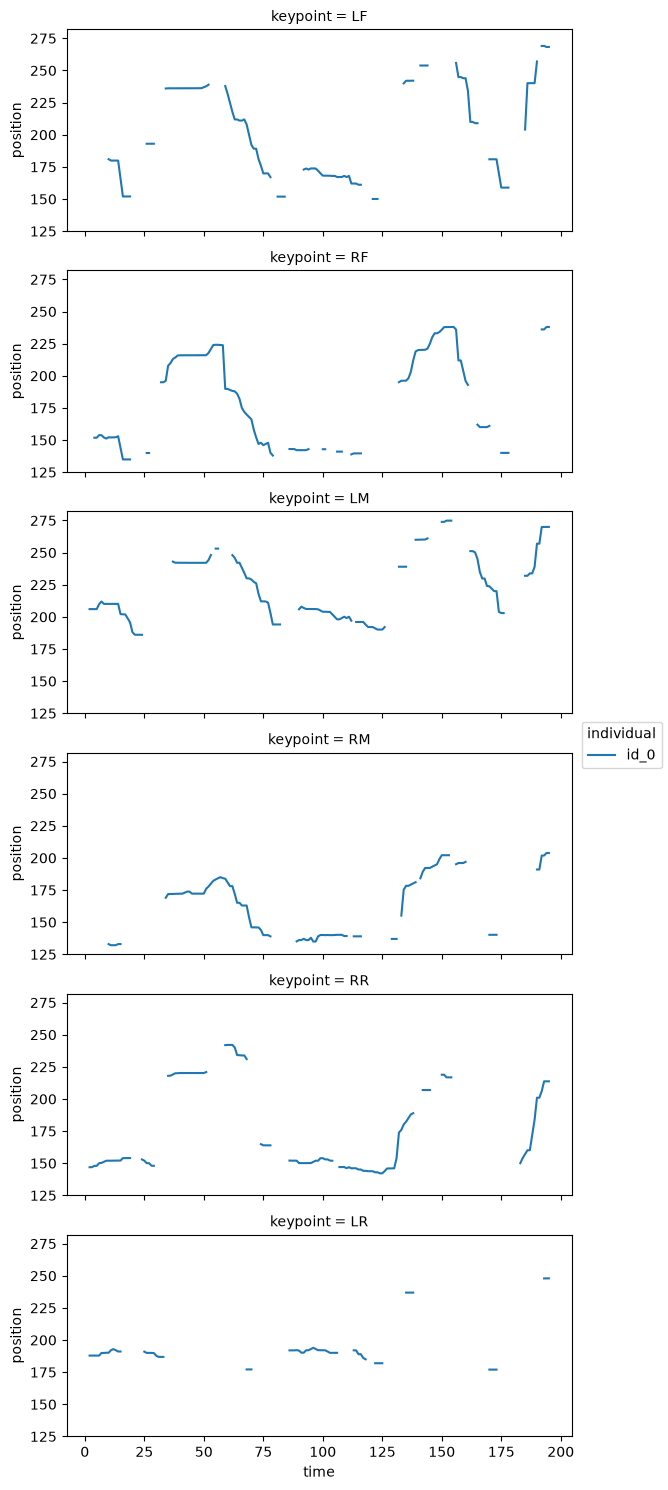

In [25]:
# x over time 
position_smooth_x = position_smooth.sel(keypoint=["LF","RF","LM", "RM", "RR", "LR"], space="x")

# y over time 
position_smooth_y = position_smooth.sel(keypoint=["LF","RF","LM", "RM", "RR", "LR"], space="y")

# plot each keypoint position x over time 
position_smooth_x.plot.line(
    x="time",row="keypoint", aspect=2, size=2.5
)

# plot each keypoint position y over time
position_smooth_y.plot.line(
    x="time",row="keypoint", aspect=2, size=2.5
)

## Interpolation
Use the function : interpolate over time with the method = linear.

In [26]:
position_interpolated = interpolate_over_time(position_smooth, method="linear")

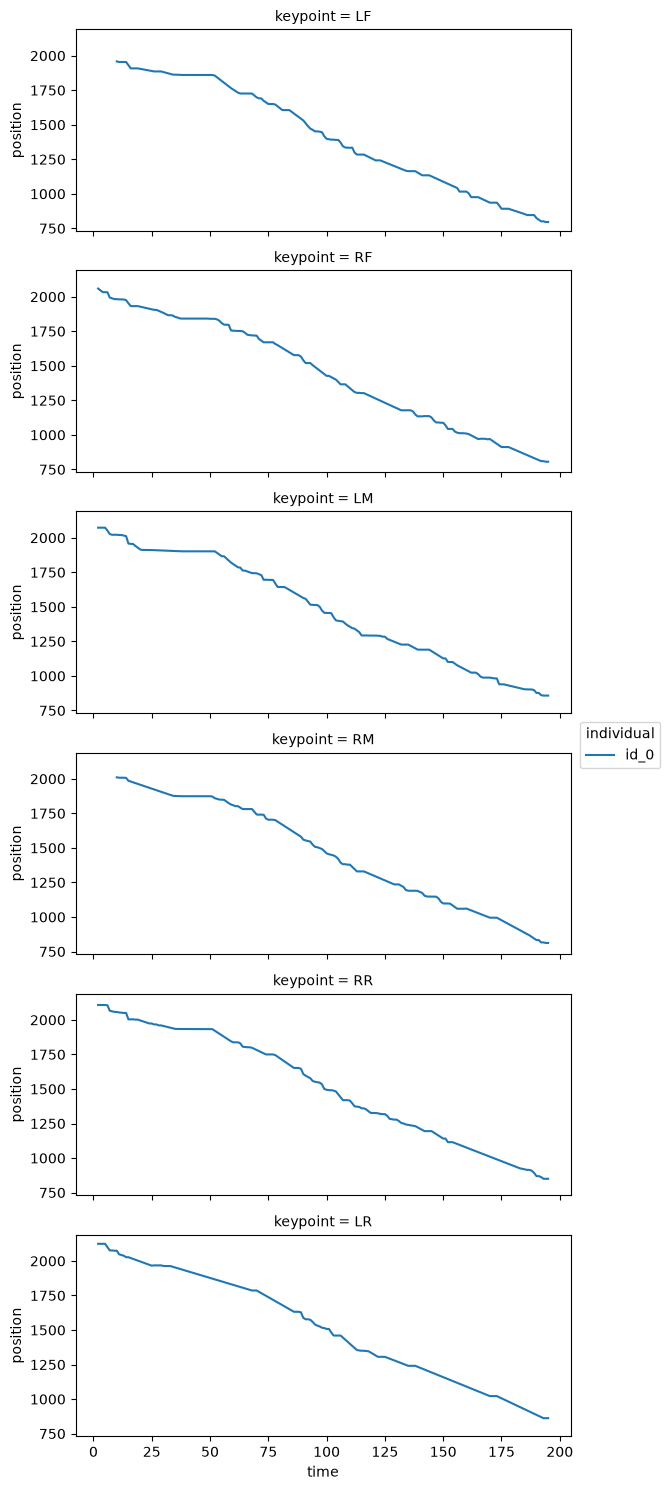

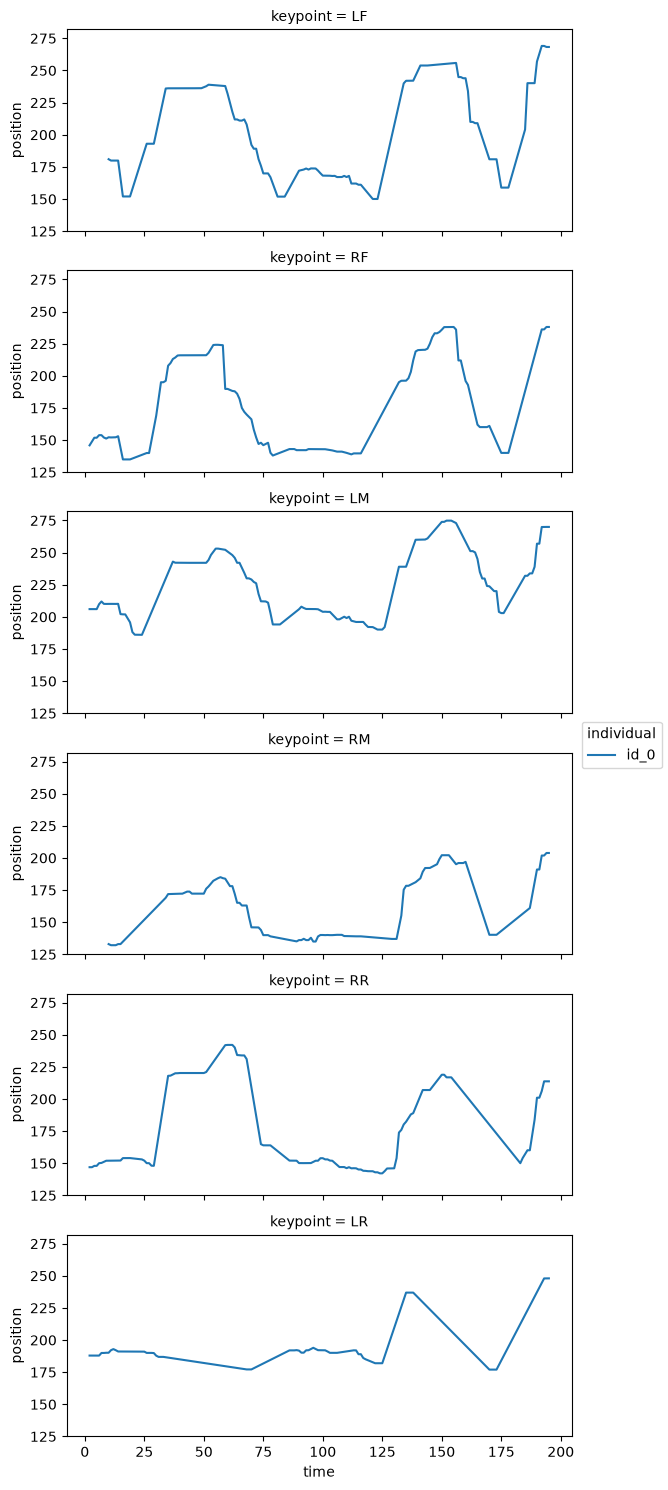

In [27]:
# x over time 
position_interpolated_x = position_interpolated.sel(keypoint=["LF","RF","LM", "RM", "RR", "LR"], space="x")

# y over time 
position_interpolated_y = position_interpolated.sel(keypoint=["LF","RF","LM", "RM", "RR", "LR"], space="y")

# plot each keypoint position x over time 
position_interpolated_x.plot.line(
    x="time",row="keypoint", aspect=2, size=2.5
)

# plot each keypoint position y over time
position_interpolated_y.plot.line(
    x="time",row="keypoint", aspect=2, size=2.5
)

# Focus on only one paw : Front Left

In total the fly did ~33 steps with her front left leg.

| Number of step | Number frame start | Number frame stop |
|----------------|--------------------|-------------------|
| 1 | 0 | 5 |
| 2 | 5 | 11 |
| 3 | 11 | 16 |
| 4 | 16 | 27 |
| 5 | 0 | 5 |
| 6 | 0 | 5 |
| 7 | 0 | 5 |
| 8 | 0 | 5 |
| 9 | 0 | 5 |
| 10 | 0 | 5 |
| 11 | 0 | 5 |
| 12 | 0 | 5 |
| 13 | 0 | 5 |
| 14 | 0 | 5 |
| 15 | 0 | 5 |
| 16 | 0 | 5 |
| 17 | 0 | 5 |
| 18 | 0 | 5 |
| 19 | 0 | 5 |
| 20 | 0 | 5 |
| 21 | 0 | 5 |
| 22 | 0 | 5 |
| 23 | 0 | 5 |
| 24 | 0 | 5 |
| 25 | 0 | 5 |
| 26 | 0 | 5 |
| 27 | 0 | 5 |
| 28 | 0 | 5 |
| 29 | 0 | 5 |
| 30 | 0 | 5 |
| 31 | 0 | 5 |
| 32 | 0 | 5 |
| 33 | 0 | 5 |


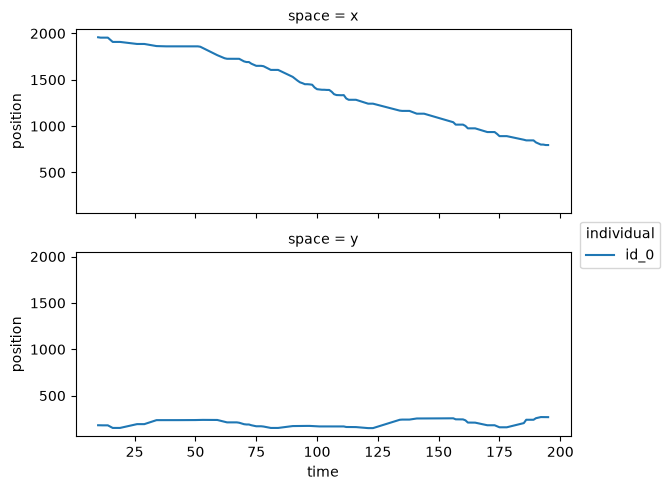

In [28]:
position_interpolated.sel(keypoint="LF").plot.line(
    x="time",row="space", aspect=2, size=2.5
)

# Region of interest 
In our video, we need only a specific region where the fly is walking. 
We use the ROI to define it, so after we can select that part and compute vectors that we need. 

## ROI
We selected in Napari different region of interest : 
- R1 : Left black band [rois0]
- R2 : Right black band [rois1]
- R1R2 : Walking horizontal axis  [rois2]
- R3 : Honrizontal axis  [rois3]
- R4 : Left horizontal axis until left black band [rois4]
- R5 : Right horizontal axis : from right black band to the end [rois5]
- R6 : Vertical axis [rois6]

![Fly : Regions of interest]("/Users/margotrefuge/osss/data/fly_top_view/rois_fly.png")

In [29]:
# Saved Rois on napari and now loads them
rois = load_rois("/Users/margotrefuge/osss/data/fly_top_view/rois_regions.geojson" )
print(f"Loaded {len(rois)} regions: {[r.name for r in rois]}")

Loaded 7 regions: ['R1', 'R2', 'R1R2', 'R3', 'R4', 'R5', 'R6']


In [30]:
# Assing real name 
left_band = rois[0]
right_band = rois[1]
walking_axis = rois[2]
h_axis = rois[3]
left_h_axis = rois[4]
right_h_axis = rois[5]
v_axis = rois[6]

# Scatter Plot 
We are doing a scatter plot on a specific keypoint : front left to see cluster and then we can use centroid and calcul distance between them. 


In [31]:
# Scatter plot : variables 

# x axis position : 
lf_pos_x = position_interpolated_x.sel(keypoint="LF")

# y axis position : 
lf_pos_y = position_interpolated_y.sel(keypoint="LF")

In [32]:
import matplotlib.pyplot as plt

In [ ]:
plt.scatter(x = lf_pos_x,
            y = lf_pos_y,
            alpha=0.5)

plt.axis('equal')

(np.float64(737.7838134765625),
 np.float64(2016.1981201171875),
 np.float64(144.07879791259765),
 np.float64(275.04818572998045))

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


In [45]:
%matplotlib qt

Vector for step 

plt

In [ ]:
step_count = np.arange(1,34)
step_count

frame_start = [0, 5, 11, 16, 27, 34, 38 ]

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33])